# NBXX: Revised population synthesis pipeline

This notebook will hold the final version of the population synthesis pipeline, for both the linear interpolation and surrogate model versions. Consistency checks, quality tests and comparisons can be found here, as well as instructions for how to use the tool. The main code should be reserved to one of the modules in `../src`.

In [40]:
nb_id = "xx"

## Setup

In [41]:
from pathlib import Path
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import astropy.units as u
import astropy.constants as ct
from astropy.cosmology import WMAP9 as cosmo
from scipy.interpolate import interp1d

from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

import mesa_reader as mr

import sys
sys.path.append('..')
from src.binary import eggleton_rl1_radius, a_from_p, marchant_l2_radius
from src.util import DATA_DIR, MESA_DATA_DIR, build_logbump35_cmap, savefig_base
from src.constants import Z_SUN
FIGURE_FOLDER = Path(f'../figures/nb{nb_id}')
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

OUTPUT_FOLDER = DATA_DIR / 'nb_output' / f'nb{nb_id}'
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)
plt.style.use('./plotstyle.mplstyle')
pd.set_option('display.max_columns', None)

In [42]:
def savefig(fig, fname):
    savefig_base(fig, fname, nb_id, FIGURE_FOLDER)

In [43]:
from src.popsynth import PMZLinearInterpolator, PMZWindPileupModel, get_complete_core_props_df

In [44]:
fiducial00_core_props_df = get_complete_core_props_df(DATA_DIR/'00_fiducial_core_props_df.h5')

## Population synthesis

In [45]:
"""Metallicity distributions."""

from scipy.stats import norm as NormDist
from scipy.interpolate import CubicSpline

def find_metallicity_distribution(redshifts, min_logZ_COMPAS, max_logZ_COMPAS,
                                  mu0=0.035, muz=-0.23, sigma_0=0.39, 
                                  sigma_z=0.0, alpha=0.0, min_logZ=-12.0, 
                                  max_logZ=0.0, step_logZ=0.01):
    """
    Calculate the distribution of metallicities at different redshifts 
    using a log skew normal distribution. The log-normal distribution 
    is a special case of this log skew normal distribution and is 
    retrieved by setting the skewness to zero (alpha=0). Based on the 
    method in Neijssel+19. Default values retrieve the dP/dZ 
    distribution used in Neijssel+19. See van Son+2022 for skewed 
    log-normal distribution.

    NOTE: This assumes that metallicities in COMPAS are drawn from a 
    flat-in-log distribution!

    Args:
        max_redshift       --> [float] Max redshift for calculation
        redshift_step      --> [float] Step used in redshift calculation
        min_logZ_COMPAS    --> [float] Min logZ value that COMPAS samples
        max_logZ_COMPAS    --> [float] Max logZ value that COMPAS samples
        mu0                --> [float] Location (mean in normal) at z=0
        muz                --> [float] Redshift scaling of location
        sigma_0            --> [float] Scale (variance in normal) at z=0
        sigma_z            --> [float] Redshift scaling of the scale
        alpha              --> [float] Shape (skewness, alpha=0 gives 
                                  normal dist as in Neijssel+19)
        min_logZ           --> [float] Min logZ for dPdlogZ calculation
        max_logZ           --> [float] Max logZ for dPdlogZ calculation
        step_logZ          --> [float] Step size for logZ range

    Returns:
        dPdlogZ            --> [2D float array] Probability of getting a 
                                  particular logZ at a certain redshift
        metallicities      --> [list of floats] Metallicities at which 
                                  dPdlogZ is evaluated
        p_draw_metallicity --> [float] Probability of drawing a certain 
                                  metallicity in COMPAS
    """
    # Log-linear redshift dependence of sigma
    sigma = sigma_0 * 10**(sigma_z * redshifts)

    # Mean metallicities evolve with redshift (Langer & Norman 2006)
    mean_metallicities = mu0 * 10**(muz * redshifts)

    # Rewrite expected value of log-skew-normal to retrieve mu
    beta = alpha / (np.sqrt(1 + alpha**2))
    PHI = NormDist.cdf(beta * sigma)
    mu_metallicities = np.log(mean_metallicities / 2. / 
                              (np.exp(0.5 * sigma**2) * PHI))

    # Create a range of metallicities (x-values or random variables)
    log_metallicities = np.arange(min_logZ, max_logZ + step_logZ, step_logZ)
    metallicities = np.exp(log_metallicities)

    # Probabilities of log-skew-normal (without 1/Z factor)
    dPdlogZ = (2. / sigma[:, np.newaxis] * 
               NormDist.pdf((log_metallicities - mu_metallicities[:, np.newaxis]) / sigma[:, np.newaxis]) * 
               NormDist.cdf(alpha * (log_metallicities - mu_metallicities[:, np.newaxis]) / sigma[:, np.newaxis]))

    # Normalize distribution over all metallicities
    norm = dPdlogZ.sum(axis=-1) * step_logZ
    dPdlogZ = dPdlogZ / norm[:, np.newaxis]

    # Flat-in-log distribution for sampled metallicity in COMPAS
    p_draw_metallicity = 1 / (max_logZ_COMPAS - min_logZ_COMPAS)

    return dPdlogZ, metallicities, p_draw_metallicity

def get_metallicity_distribution_ip(redshift):
    mu0 = 0.025
    muz = -0.049
    sigma0 = 1.122
    sigmaz = 0.049
    alpha = -1.778
    min_logZ = -12.0
    max_logZ = 0.0
    step_logZ = 0.01
    min_Z = 0.0005 * Z_SUN
    max_Z = Z_SUN
    dPdlogZ, metallicities, p_draw_metallicity = find_metallicity_distribution(
        redshifts=np.asarray([redshift]),
        min_logZ_COMPAS=np.log(min_Z),
        max_logZ_COMPAS=np.log(max_Z),
        mu0=mu0,
        muz=muz,
        sigma_0=sigma0,
        sigma_z=sigmaz,
        alpha=alpha,
        min_logZ=min_logZ,
        max_logZ=max_logZ,
        step_logZ=step_logZ
        )
    spline = CubicSpline(np.log10(metallicities/Z_SUN), dPdlogZ[0])
    return spline

In [46]:
class _CheMaskGetter:
    def __init__(self, che_m_min, che_p_min, che_lower_slope, che_upper_slope):
        self.che_m_min = che_m_min
        self.che_p_min = che_p_min
        self.che_lower_slope = che_lower_slope
        self.che_upper_slope = che_upper_slope

    def __call__(self, m, p):
        p_lower = self.che_lower_slope * (m - self.che_m_min) + self.che_p_min
        p_upper = self.che_upper_slope * (m - self.che_m_min) + self.che_p_min
        return (m >= self.che_m_min) & (p >= p_lower) & (p <= p_upper)

In [47]:
import os
from functools import partial
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import numpy as np

from src.popsynth import FinalVarModel as PSFinalVarModel

class PopSynth:

    # CHE window defaults — override at class or instance level as needed
    CPU_COUNT = os.cpu_count() or 1
    CHE_M_MIN = 20.0
    CHE_P_MIN = 0.4
    CHE_LOWER_SLOPE = 0.002
    CHE_UPPER_SLOPE = 0.01

    def __init__(self, core_props_df, ip_cut_non_he_depl=False, title='new', n_processes=None, verbose=True):
        self.core_props_df = core_props_df
        self.ip_cut_non_he_depl = ip_cut_non_he_depl
        self.title = title
        self.n_processes = n_processes or self.CPU_COUNT
        self.verbose = verbose
        self.models = {}  # var -> PSFinalVarModel, populated by fit()

    def _make_che_mask_getter(self):
        return _CheMaskGetter(self.CHE_M_MIN, self.CHE_P_MIN, self.CHE_LOWER_SLOPE, self.CHE_UPPER_SLOPE)

    @staticmethod
    def _resolve_model(var, requested_model):
        """Analytical model only supports mass vars and log_t_d; fall back otherwise."""
        if requested_model == 'analytical':
            if var.startswith('m_') or var == 'log_t_d':
                return 'analytical'
            else:
                if True:  # could be gated on verbose
                    print(f"Variable '{var}' not supported by analytical model. Using interpolator.")
                return 'interpolator'
        return 'interpolator'

    def fit(self, vars, model='interpolator'):
        """Instantiate and fit a PSFinalVarModel for each variable in vars.

        Parameters
        ----------
        vars : list of str
            Variables to fit models for (e.g. ['m_f', 'x_f', 'log_t_d']).
        model : str
            'interpolator' or 'analytical'. Analytical is silently downgraded
            to interpolator for variables it cannot handle.
        """
        che_mask_getter = self._make_che_mask_getter()
        for var in vars:
            resolved = self._resolve_model(var, model)
            if self.verbose:
                print(f"Fitting '{var}' with model='{resolved}'...")
            m = PSFinalVarModel(
                core_props_df=self.core_props_df,
                var=var,
                model=resolved,
                che_mask_getter=che_mask_getter,
                cut_non_he_depl=self.ip_cut_non_he_depl,
                title=self.title,
                n_processes=self.n_processes,
                verbose=self.verbose,
            )
            m.fit()
            self.models[var] = m

    def predict(self, job, var, apply_che_mask=True):
        """Run prediction for a single variable on a job array.

        Parameters
        ----------
        job : np.ndarray, shape (n, 3+)
            Columns: [metallicity, m_zams, p_spin_zams, ...]
        var : str
            Variable to predict. Must have been fitted via fit().
        apply_che_mask : bool
        """
        if var not in self.models:
            raise ValueError(f"No fitted model for '{var}'. Call fit(['{var}', ...]) first.")
        return self.models[var].predict(job, apply_che_mask=apply_che_mask)

    def parallel_set_sample_var(self, sample, var, var_col_i, apply_che_mask=True):
        run_job = partial(self.predict, var=var, apply_che_mask=apply_che_mask)

        split_indices = np.array_split(np.arange(len(sample)), self.n_processes)
        jobs = [sample[idx] for idx in split_indices]

        with ProcessPoolExecutor(max_workers=self.n_processes) as executor:
            futures = {
                executor.submit(run_job, job): job_index
                for job_index, job in enumerate(jobs)
            }
            for future in tqdm(as_completed(futures), total=len(futures), desc=f'Collecting {var}'):
                job_index = futures[future]
                try:
                    result = future.result()
                except Exception as e:
                    print(f'Error in job {job_index}: {e}')
                    continue
                sample[split_indices[job_index], var_col_i] = result

        return sample

    def draw_pop(
        self,
        vars,
        apply_che_mask=True,
        metallicity='loguniform',
        redshift=1.,
        res=int(1e8),
        min_m=20,
        max_m=300,
        min_p=0.1,
        max_p=4,
        min_zdivzsun=0.1,
        max_zdivzsun=1.0,
        write_to_disk=False,
    ):
        unfitted = [v for v in vars if v not in self.models]
        if unfitted:
            raise ValueError(f"No fitted model for variables: {unfitted}. Call fit() first.")

        n_sample = int(res / 100)

        sample_masses = np.linspace(min_m, max_m, res)
        sample_probs = sample_masses ** -2.3 / np.sum(sample_masses ** -2.3)
        sample_masses = np.random.choice(sample_masses, p=sample_probs, size=n_sample)

        sample_periods = np.linspace(np.log10(min_p), np.log10(max_p), res)
        sample_periods = 10. ** np.random.choice(sample_periods, size=n_sample)

        if isinstance(metallicity, (int, float)):
            sample_zs = np.tile(metallicity, n_sample)
        elif metallicity == 'loguniform':
            sample_zs = np.linspace(np.log10(min_zdivzsun), np.log10(max_zdivzsun), res)
            sample_zs = 10. ** np.random.choice(sample_zs, size=n_sample)
        elif metallicity == 'realistic':
            dpdlogz = get_metallicity_distribution_ip(redshift)
            sample_zs = np.linspace(np.log10(min_zdivzsun), np.log10(max_zdivzsun), res)
            sample_probs = dpdlogz(sample_zs) / np.sum(dpdlogz(sample_zs))
            sample_zs = 10. ** np.random.choice(sample_zs, p=sample_probs, size=n_sample)
        else:
            raise ValueError(
                f"Options for metallicity are a fixed value (int/float), 'loguniform', or 'realistic'. Got '{metallicity}'."
            )

        sample = np.array([
            sample_zs,
            sample_masses,
            sample_periods,
            *np.zeros((len(vars), n_sample))
        ]).T

        for i_var, var in enumerate(vars):
            sample = self.parallel_set_sample_var(
                sample=sample,
                var=var,
                var_col_i=i_var + 3,
                apply_che_mask=apply_che_mask,
            )

        if write_to_disk:
            self.save_sample_msample(sample, min_zdivzsun=min_zdivzsun, max_zdivzsun=max_zdivzsun, res=res)

        return sample

    def save_sample_msample(self, sample, min_zdivzsun, max_zdivzsun, res):
        msample = sample[sample[:, -1] <= np.log10(t_h)].copy()
        tag = f'{self.title}_ip_pop_minz{min_zdivzsun}_maxz{max_zdivzsun}_res{res:.0e}_enhanced_w'
        np.save(DATA_DIR / f'{tag}.npy', sample)
        print(f'Saved {len(sample)} stars to {DATA_DIR / f"{tag}.npy"}')
        np.save(DATA_DIR / f'{tag}_mergers_only.npy', msample)
        print(f'Saved {len(msample)} mergers to {DATA_DIR / f"{tag}_mergers_only.npy"}')

In [106]:
def get_standard_sample(core_props_df, title='', write_to_disk=False, n_processes=4, verbose=True):
    vars=[
        'm_f',
        'p_orb_f',
        'x_f',
        'x_min_f',
        'log_t_d',
        'm_tams',
        'x_tams'
    ]
    model = 'interpolator'

    ip_cut_non_he_depl=True

    popsynth = PopSynth(
        core_props_df=core_props_df, 
        ip_cut_non_he_depl=ip_cut_non_he_depl, 
        title=title, 
        n_processes=n_processes, 
        verbose=verbose
        )
    popsynth.fit(
        vars=vars,
        model=model
    )

    draw_pop_kwargs = dict(
        vars=vars,
        apply_che_mask=True,
        metallicity='loguniform',
        redshift=1.,
        res=int(1e7),
        min_m=20,
        max_m=300,
        min_p=0.1,
        max_p=4,
        min_zdivzsun=0.0005,
        max_zdivzsun=1.0,
        write_to_disk=write_to_disk,
    )

    sample = popsynth.draw_pop(**draw_pop_kwargs)

    return sample

In [122]:
from astropy.cosmology import WMAP9
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

T_H = WMAP9.age(0).to('yr').value


def get_msample(sample):
    return sample[sample[:, -1] < np.log10(T_H)]


def plot_mf_hist(sample, msample, ax, legend):
    bins = np.linspace(5, 100, 50)
    ax.hist(msample[:, 3], bins=bins, density=True, alpha=0.5, label='$t_\\mathrm{d}<t_\\mathrm{H}$')
    ax.hist(sample[:, 3], bins=bins, density=True, alpha=0.5, label='full sample')
    ax.vlines(35, 0, 1, color='k', lw=0.8)
    ax.set_ylim(0, 0.05)
    ax.set_xlabel('$M_\\mathrm{f} \\, / \\, \\mathrm{M}_\\odot$')
    ax.set_ylabel('$\\mathrm{d}N/\\mathrm{d}M_f\\,(\\mathrm{M}_\\odot^{-1})$')
    if legend:
        ax.legend(frameon=False)


def plot_mf_stacked(sample, ax, legend):
    bins = np.linspace(5, 100, 50)
    cmap = cm.viridis
    seg_edges = np.logspace(-2, 0, 7)
    groups, labels = [], []
    for i, (lo, hi) in enumerate(zip(seg_edges[:-1], seg_edges[1:])):
        mask = (
            (sample[:, 0] >= lo) & (sample[:, 0] <= hi)
            if i == len(seg_edges) - 2
            else (sample[:, 0] >= lo) & (sample[:, 0] < hi)
        )
        groups.append(sample[mask, 3])
        labels.append(f"${np.log10(lo):.1f}\\leq\\log Z/\\mathrm{{Z}}_\\odot<{np.log10(hi):.1f}$")
    colors = [cmap(i / (len(groups) - 1)) for i in range(len(groups))]
    bottom = np.zeros(len(bins) - 1)
    for data, color, label in zip(groups, colors, labels):
        counts, _ = np.histogram(data, bins=bins, density=True)
        ax.bar(
            (bins[:-1] + bins[1:]) / 2,
            counts,
            width=np.diff(bins),
            bottom=bottom,
            color=color,
            edgecolor='black',
            linewidth=0.5,
            align='center',
            label=label,
        )
        bottom += counts
    ax.set_ylim(0, 0.25)
    ax.vlines(35, *ax.get_ylim(), color='k', lw=0.8)
    ax.set_xlabel(r'$M_\mathrm{f} \,/\, \mathrm{M}_\odot$')
    ax.set_ylabel(r'$\mathrm{d}N/\mathrm{d}M_f\,(\mathrm{M}_\odot^{-1})$')
    if legend:
        ax.legend(frameon=False, loc='upper right', bbox_to_anchor=(1, 1))


def plot_mf_kde(sample, msample, ax, legend):
    intervals = np.logspace(-2, 0, 7)
    midpoints = np.sqrt(intervals[:-1] * intervals[1:])
    log_midpoints = np.log10(midpoints)
    norm = plt.Normalize(log_midpoints.min(), log_midpoints.max())
    cmap = plt.cm.viridis
    ylim = (1e-3, 3e-1)

    for i in range(len(intervals) - 1):
        mask = (sample[:, 0] >= intervals[i]) & (sample[:, 0] < intervals[i + 1])
        sns.kdeplot(sample[mask, 3], ax=ax, color=cmap(norm(log_midpoints[i])), linestyle='--')

    for i in range(len(intervals) - 1):
        mask = (
            (msample[:, 0] >= intervals[i])
            & (msample[:, 0] < intervals[i + 1])
            & ~np.isnan(msample[:, 3])
        )
        sns.kdeplot(msample[mask, 3], ax=ax, color=cmap(norm(log_midpoints[i])), linestyle='-')

    ax.vlines(35, 0, ylim[1], color='k', lw=0.8)
    ax.text(35, ylim[1] * 0.8, '$35\\,\\mathrm{M}_\\odot$', ha='left', va='center', fontsize=14)
    ax.set_ylim(ylim)
    ax.set_yscale('log')
    ax.set_xlim(1, 110)
    ax.set_xlabel('$M_\\mathrm{f} \\, / \\, \\mathrm{M}_\\odot$')
    ax.set_ylabel('$\\mathrm{d}N/\\mathrm{d}M_f\\,(\\mathrm{M}_\\odot^{-1})$')

    metallicity_handles = [
        Patch(color=cmap(norm(log_midpoints[i])),
              label=f"${np.log10(intervals[i]):.1f}<\\log Z/\\mathrm{{Z}}_\\odot\\leq{np.log10(intervals[i+1]):.1f}$")
        for i in range(len(midpoints))
    ]
    line_handles = [
        Line2D([0], [0], color='k', linestyle='-', label='$t_d < t_h$'),
        Line2D([0], [0], color='k', linestyle='--', label='Full sample'),
    ]
    if legend:
        ax.legend(handles=metallicity_handles + line_handles, frameon=False,
                bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)


def plot_results_panel(sample, figsize=(14,10), title=None):
    msample = get_msample(sample)
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.35)

    ax_hist = fig.add_subplot(gs[1, 0])
    ax_stacked = fig.add_subplot(gs[1, 1])
    ax_kde = fig.add_subplot(gs[0, :])

    plot_mf_kde(sample, msample, ax_kde, legend=True)
    plot_mf_hist(sample, msample, ax_hist, legend=True)
    plot_mf_stacked(sample, ax_stacked, legend=False)

    if title:
        fig.suptitle(title, fontsize=14)

    return fig


def plot_results_panel_df(sample_df, x_col='m_f', figsize=(14, 10), title=None):
    X_LABELS = {
        'm_zams': '$M_\\mathrm{ZAMS}/M_\\odot$',
        'm_f': '$M_\\mathrm{f}/M_\\odot$',
        'm_tams': '$M_\\mathrm{TAMS}/M_\\odot$',
    }

    # Build arrays matching the format the individual plot functions expect
    # sample[:, 0] = z_div_zsun, sample[:, 3] = x_col
    sample = np.column_stack([
        sample_df.z_div_zsun.values,
        np.zeros(len(sample_df)),  # placeholder col 1
        np.zeros(len(sample_df)),  # placeholder col 2
        sample_df[x_col].values,
        sample_df.log_t_d.values,  # last col, used by get_msample
    ])
    sample = sample[sample[:, -2] > 0.]
    msample = get_msample(sample)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.35)

    ax_hist = fig.add_subplot(gs[1, 0])
    ax_stacked = fig.add_subplot(gs[1, 1])
    ax_kde = fig.add_subplot(gs[0, :])

    plot_mf_kde(sample, msample, ax_kde, legend=True)
    plot_mf_hist(sample, msample, ax_hist, legend=True)
    plot_mf_stacked(sample, ax_stacked, legend=False)

    # Override x labels with the correct variable
    xlabel = X_LABELS.get(x_col, x_col)
    for ax in [ax_hist, ax_stacked, ax_kde]:
        ax.set_xlabel(xlabel)

    if title:
        fig.suptitle(title, fontsize=14)

    return fig

In [107]:
def renzo_ppisn(m_tot, m_co, z):
    delta_ppi = (
        (0.0006 * np.log10(z) + 0.0054)
        * (m_co - 34.8) ** 3
        - 0.0013 * (m_co - 34.8) ** 2
    )
    return m_tot - delta_ppi
    

def get_post_pi_mass(sample_df, m_he_tams_ppisne_th=55, m_he_tams_pisne_th=70, m_he_tams_pd_th=135):
    m_post_pi = np.zeros(sample_df.shape[0])
    fate_type = np.asarray(['missing'] * sample_df.shape[0], dtype=str)

    stable_mask = np.zeros(sample_df.shape[0], dtype=bool)
    stable_mask[sample_df.m_tams < m_he_tams_ppisne_th] = True

    ppsin_mask = np.zeros(sample_df.shape[0], dtype=bool)
    ppsin_mask[(sample_df.m_tams >= m_he_tams_ppisne_th) & (sample_df.m_tams < m_he_tams_pisne_th)] = True

    pisn_mask = np.zeros(sample_df.shape[0], dtype=bool)
    pisn_mask[(sample_df.m_tams >= m_he_tams_pisne_th) & (sample_df.m_tams < m_he_tams_pd_th)] = True

    photodisintegration_mask = np.zeros(sample_df.shape[0], dtype=bool)
    photodisintegration_mask[sample_df.m_tams >= m_he_tams_pd_th] = True

    fate_type[stable_mask] = ['ccsn'] * stable_mask.sum()
    m_post_pi[stable_mask] = sample_df.m_f[stable_mask].to_numpy()

    fate_type[ppsin_mask] = ['ppisn'] * ppsin_mask.sum()
    m_post_pi[ppsin_mask] = renzo_ppisn(sample_df.m_f[ppsin_mask].to_numpy(), sample_df.m_f[ppsin_mask].to_numpy(), sample_df.z_div_zsun[ppsin_mask].to_numpy()*Z_SUN)

    fate_type[pisn_mask] = ['pisn'] * pisn_mask.sum()
    m_post_pi[pisn_mask] = np.zeros(sample_df[pisn_mask].shape[0], dtype=sample_df.m_f.dtype)

    fate_type[photodisintegration_mask] = ['pd'] * photodisintegration_mask.sum()
    m_post_pi[photodisintegration_mask] = sample_df.m_f[photodisintegration_mask].to_numpy()

    sample_df['m_post_pi'] = m_post_pi
    sample_df['fate_type'] = fate_type

    print(f'len missing: {(fate_type == "missing").sum()}')
    print(f'len stable: {stable_mask.sum()}')
    print(f'len ppisn: {ppsin_mask.sum()}')
    print(f'len pisn: {pisn_mask.sum()}')
    print(f'len pd: {photodisintegration_mask.sum()}')
    print(f'len total: {stable_mask.sum() + ppsin_mask.sum() + pisn_mask.sum() + photodisintegration_mask.sum()}')
    return sample_df

In [108]:
fiducial00_core_props_df = get_complete_core_props_df(DATA_DIR/'00_fiducial_core_props_df.h5')
sample00 = get_standard_sample(fiducial00_core_props_df, title='00fiducial', write_to_disk=True, n_processes=8)

Fitting 'm_f' with model='interpolator'...
Fitting 'p_orb_f' with model='interpolator'...
Fitting 'x_f' with model='interpolator'...
Fitting 'x_min_f' with model='interpolator'...
Fitting 'log_t_d' with model='interpolator'...
Fitting 'm_tams' with model='interpolator'...
Fitting 'x_tams' with model='interpolator'...


Saved 100000 stars to ../data/00fiducial_ip_pop_minz0.0005_maxz1.0_res1e+07_enhanced_w.npy
Saved 701 mergers to ../data/00fiducial_ip_pop_minz0.0005_maxz1.0_res1e+07_enhanced_w_mergers_only.npy


In [117]:
def get_sample_df(sample):
    cols = ['z_div_zsun', 'm_zams', 'p_spin_zams', 'm_f', 'p_orb_f', 'x_f', 'min_x_f', 'log_t_d', 'm_tams', 'x_tams']
    sample_df = pd.DataFrame(sample, columns=cols)
    sample_df = get_post_pi_mass(sample_df, m_he_tams_ppisne_th=55)
    return sample_df


In [118]:
sample00_df_full = get_sample_df(sample00)

len missing: 99299
len stable: 359
len ppisn: 166
len pisn: 176
len pd: 0
len total: 701


/home/hd/hd_hd/hd_lt355/.pyenv/versions/cher/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


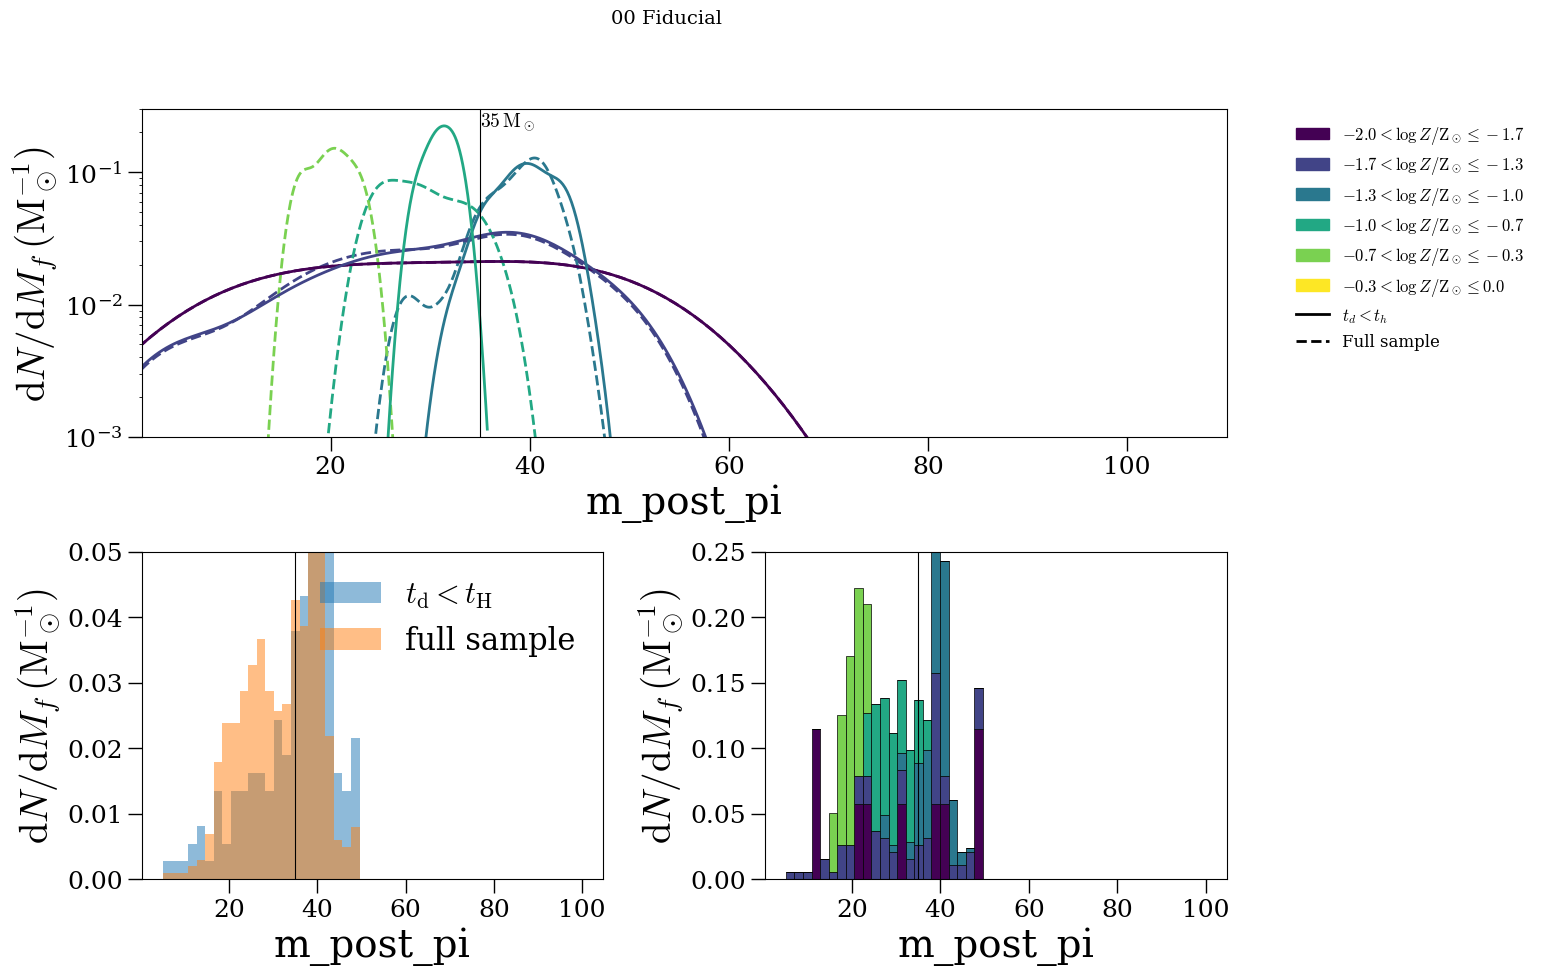

In [123]:
fiducial00_panel_fig = plot_results_panel_df(sample00_df_full, x_col='m_post_pi', title='00 Fiducial')

/tmp/ipykernel_3450029/830576680.py:75: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(sample[mask, 3], ax=ax, color=cmap(norm(log_midpoints[i])), linestyle='--')
/home/hd/hd_hd/hd_lt355/.pyenv/versions/cher/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


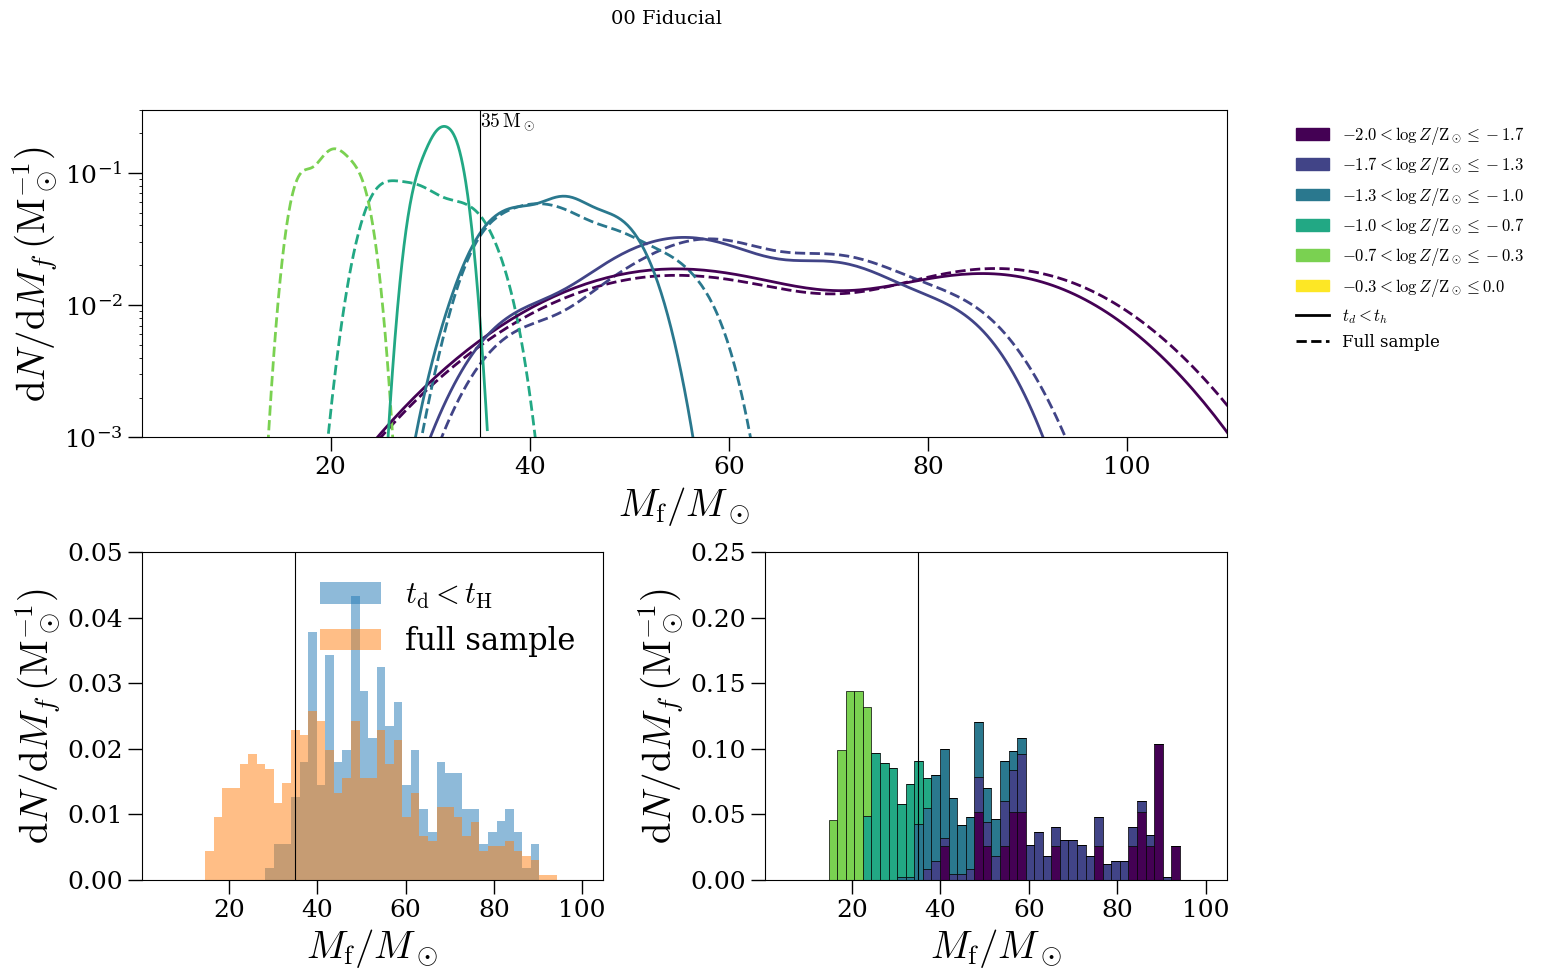

In [ ]:
fiducial00_panel_fig = plot_results_panel_df(sample00_df_full, x_col='m_f', title='00 Fiducial')

### Test grids

In [ ]:
! 

In [124]:
core_props_df_path_dict = {
    '03_strong_winds' : DATA_DIR / '03_strong_winds_core_props_df.h5',
    '04_flat_m_winds' : DATA_DIR / '04_flat_m_winds_core_props_df.h5',
    '05_steep_m_winds' : DATA_DIR / '05_steep_m_winds_core_props_df.h5',
    '06_flat_z_winds' : DATA_DIR / '06_flat_z_winds_core_props_df.h5',
    '07_steep_z_winds' : DATA_DIR / '07_steep_z_winds_core_props_df.h5',
    '08_late_wind_transition' : DATA_DIR / '08_late_wind_transition_core_props_df.h5',
    '09_early_wind_transition' : DATA_DIR / '09_early_wind_transition_core_props_df.h5',
    '10_inefficient_mix' : DATA_DIR / '10_inefficient_mix_core_props_df.h5',
    '11_efficient_mix' : DATA_DIR / '11_efficient_mix_core_props_df.h5'
}

In [ ]:
sample_df_dict = {}

for title, path in core_props_df_path_dict.items():
    core_props_df = get_complete_core_props_df(path)
    sample = get_standard_sample(core_props_df, title=title, write_to_disk=True, n_processes=8)
    sample_df = get_sample_df(sample)
    sample_df_dict[title] = sample_df

Fitting 'm_f' with model='interpolator'...
Fitting 'p_orb_f' with model='interpolator'...
Fitting 'x_f' with model='interpolator'...
Fitting 'x_min_f' with model='interpolator'...
Fitting 'log_t_d' with model='interpolator'...
Fitting 'm_tams' with model='interpolator'...
Fitting 'x_tams' with model='interpolator'...


Saved 100000 stars to ../data/03_strong_winds_ip_pop_minz0.0005_maxz1.0_res1e+07_enhanced_w.npy
Saved 62 mergers to ../data/03_strong_winds_ip_pop_minz0.0005_maxz1.0_res1e+07_enhanced_w_mergers_only.npy
len missing: 99938
len stable: 40
len ppisn: 15
len pisn: 7
len pd: 0
len total: 62
Fitting 'm_f' with model='interpolator'...
Fitting 'p_orb_f' with model='interpolator'...
Fitting 'x_f' with model='interpolator'...
Fitting 'x_min_f' with model='interpolator'...
Fitting 'log_t_d' with model='interpolator'...
Fitting 'm_tams' with model='interpolator'...
Fitting 'x_tams' with model='interpolator'...
